In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import torch

from src.models.baseline_cnn import (
    BaselineCNN
)

In [3]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [4]:
model = BaselineCNN()

model = model.to(DEVICE)

model

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [5]:
dummy = torch.randn(
    4,
    3,
    224,
    224
).to(DEVICE)

output = model(dummy)

print(output.shape)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(total_params)

torch.Size([4, 10])
94538


In [6]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

Total Parameters: 94,538
Trainable Parameters: 94,538


In [7]:
import torch.nn as nn
from tqdm import tqdm
from src.models.baseline_cnn import BaselineCNN

In [8]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [9]:
model = BaselineCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [10]:
class EarlyStopping:

    def __init__(
        self,
        patience=5,
        min_delta=0.0
    ):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = float("inf")
        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

In [11]:
early_stopping = EarlyStopping(
    patience=5
)

best_val_acc = 0

In [12]:
EPOCHS = 30

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [13]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss
        / len(loader)
    )

    epoch_acc = (
        correct
        / total
    )

    return epoch_loss, epoch_acc

In [14]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss
        / len(loader)
    )

    epoch_acc = (
        correct
        / total
    )

    return epoch_loss, epoch_acc

In [15]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [16]:
from torchvision import transforms
from torch.utils.data import DataLoader

from src.datasets.eurosat_dataset import EuroSATDataset

In [17]:
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

train_csv = PROCESSED_DIR / "train_spatial.csv"
val_csv = PROCESSED_DIR / "val_spatial.csv"
test_csv = PROCESSED_DIR / "test_spatial.csv"

In [18]:
EUROSAT_MEAN = (
    0.34437724,
    0.38029198,
    0.40777111
)

EUROSAT_STD = (
    0.20265734,
    0.13689059,
    0.11554374
)

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(EUROSAT_MEAN, EUROSAT_STD)
])

In [20]:
train_dataset = EuroSATDataset(
    train_csv,
    transform=train_transform
)

val_dataset = EuroSATDataset(
    val_csv,
    transform=eval_transform
)

test_dataset = EuroSATDataset(
    test_csv,
    transform=eval_transform
)

In [21]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [22]:
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

337
44
42


In [23]:
early_stopping = EarlyStopping(
    patience=5
)

best_val_acc = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")
    print("-" * 50)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            CHECKPOINT_DIR / "baseline_cnn_best.pt"
        )

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print(
            f"Early stopping triggered at epoch {epoch+1}"
        )

        break

100%|██████████| 337/337 [00:21<00:00, 15.70it/s]


Epoch [1/30]
Train Loss: 1.2631
Train Acc : 0.5495
Val Loss  : 2.1355
Val Acc   : 0.4928
--------------------------------------------------


100%|██████████| 337/337 [00:21<00:00, 15.63it/s]


Epoch [2/30]
Train Loss: 0.9092
Train Acc : 0.6751
Val Loss  : 1.8226
Val Acc   : 0.5324
--------------------------------------------------


100%|██████████| 337/337 [00:21<00:00, 15.71it/s]


...

Epoch [27/30]
Train Loss: 0.3361
Train Acc : 0.8864
Val Loss  : 1.4845
Val Acc   : 0.6748
--------------------------------------------------


100%|██████████| 337/337 [00:22<00:00, 15.19it/s]


Epoch [28/30]
Train Loss: 0.3356
Train Acc : 0.8853
Val Loss  : 1.8490
Val Acc   : 0.6417
--------------------------------------------------


100%|██████████| 337/337 [00:21<00:00, 15.60it/s]


Epoch [29/30]
Train Loss: 0.3302
Train Acc : 0.8899
Val Loss  : 1.5925
Val Acc   : 0.6399
--------------------------------------------------
Early stopping triggered at epoch 29


In [24]:
print(
    f"Best Validation Accuracy: {best_val_acc:.4f}"
)

Best Validation Accuracy: 0.6748


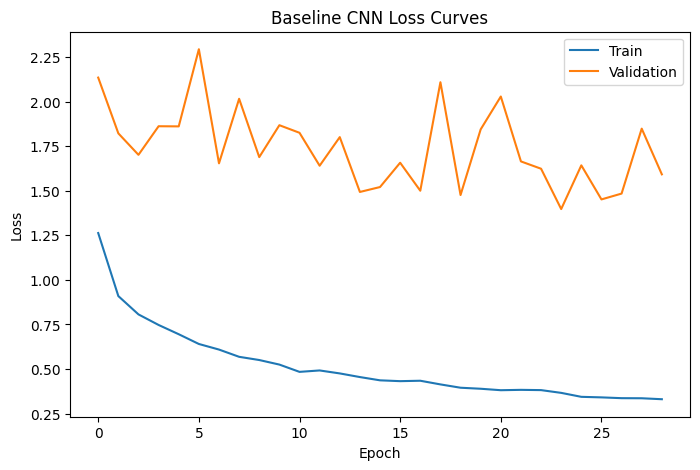

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title(
    "Baseline CNN Loss Curves"
)

plt.show()

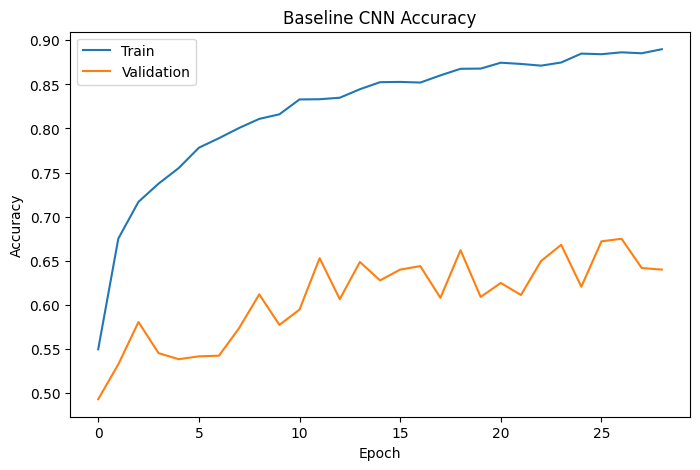

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train"
)

plt.plot(
    val_accs,
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.title(
    "Baseline CNN Accuracy"
)

plt.show()